### Test JaxTracer on Hydro Turbulence - Inverse Brems + Correlation Theta Phi

Import Libs

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

#add path
sys.path.insert(0, '../')     # import path/to/sloth

import src.core.config as config
config.jax_init(force_device = "gpu", enable_x64= True)

import core.beam as beam_initialiser
import core.domain as d
import core.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /rds/general/user/sm13118/home/dev/SLOTH/src

Disabling python multi-threading...
Initialising jax...


Default jax backend: gpu
Available devices: [CudaDevice(id=0)]


<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/SLOTH/src/processing/diagnostics.py'>

Import domain

In [2]:
base_folder = "/rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC"
path_to_file = "/xyz11_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0193"
filename = base_folder+path_to_file
#  -----------------

#load hdf
ne, dims, spacing, extras = utilIO.hdf_readin(filename, prefer_ye=True, force_override=True, verbose=True, return_tele=True, return_z=True)

print(ne.shape)

multi_x = 0
multi_y = 0
multi_z = 0

ne = np.concatenate([ne] * (multi_x + 1), axis=0)
ne = np.concatenate([ne] * (multi_y + 1), axis=1)
ne = np.concatenate([ne] * (multi_z + 1), axis=2)

dims = ne.shape

extent_x = ((dims[0]*spacing[0].v)/2) * 1e-2
extent_y = ((dims[1]*spacing[1].v)/2) * 1e-2
extent_z = ((dims[2]*spacing[2].v)/2) * 1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

del ne_x
del ne_y
del ne_z

yt : [INFO     ] 2026-03-31 22:28:18,987 Parameters: current_time              = 1.6168791515097758e-07
yt : [INFO     ] 2026-03-31 22:28:18,987 Parameters: domain_dimensions         = [1200  750  500]
yt : [INFO     ] 2026-03-31 22:28:18,988 Parameters: domain_left_edge          = [-0.1  0.   0. ]
yt : [INFO     ] 2026-03-31 22:28:18,988 Parameters: domain_right_edge         = [1.1  0.75 0.5 ]
yt : [INFO     ] 2026-03-31 22:28:18,988 Parameters: cosmological_simulation   = 0


[hdf_readin] Loaded: /rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC/xyz11_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0193
[hdf_readin] has_ye=True (prefer_ye=True)
[hdf_readin] has_sumy=True
[hdf_readin] has_tele=True
[hdf_readin] max_level=0
[hdf_readin] dims=(1200, 750, 500)
[hdf_readin] spacing=[unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length')]
(1200, 750, 500)
[0.012  0.0075 0.005 ]
extent x: 0.006000000000000001
extent y: 0.00375
extent z: 0.0025
dims x: 1200
dims y: 750
dims z: 500





In [3]:
# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 1e6

# domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6, inv_brems = False, Te = None, Z = None)

domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6, inv_brems = True, Te = extras['tele']/11604.5221, Z = extras['z'])


Predicted size in memory of domain: 1.6763806343078613 GB

Memory prior to domain creation:
 - total : 44.98828125 GB
 - free  : 40.794189453125 GB
 - used  : 4.194091796875 GB

Est. ray size in memory: 2.0563602447509766 GB
Est. domain memory limit: 10.058283805847168 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 16.227364540100098 GB

padded up-to 1200 entries.(1200, 750, 500) --> 
 --> x padded with: 0 nan's
 --> y padded with: 450 nan's
 --> z padded with: 700 nan's

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


Tracing using JaxTracer

In [57]:
# define beam parameters
lwl            =  532e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"


# --- trace and save Jones vector with inv_brems ---
# rf_jax, _, duration = p.solve((beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain, probing_extent, verbose = False)

rf_jax, rf_jax_noloss, duration = p.solve((beam_size, divergence, ne_extent,  probing_direction, beam_type, False), domain, probing_extent, lwl = lwl, verbose = False)



Number of domain batches: 1
Number of ray batches: 1

Using tuple values to create the unbatched beam, domain must be used in the same fashion.

Est. size in memory of rays (1 = 736 B): 701.904296875 MB
 --> Np = 1000000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.0025 mm's to the target depth of 0.0025 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.00038313865661621094 seconds
Completed ray trace in 55.101 seconds.


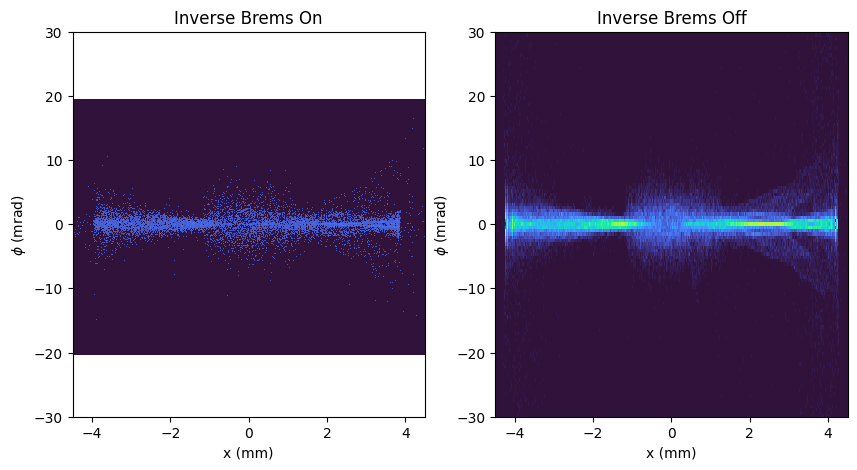

In [59]:
import matplotlib.colors as mcolors

def lens_cutoff_1d(x, phi, *, L=400, R=25):
    """
    1D lens cutoff using only x and phi information.
    """
    x = np.asarray(x, dtype=float)
    phi = np.asarray(phi, dtype=float)

    x_lens = x + L * np.tan(phi)
    mask = np.abs(x_lens) <= R
    
    return mask, x_lens

def ccd_cutoff_1d(phi, *, phi_max=None, phi_min=None):
    """
    Standalone CCD cutoff in angle space.
    Keeps only rays whose measured angle lies within the CCD range.
    """
    phi = np.asarray(phi, dtype=float)

    if phi_max is None and phi_min is None:
        return np.isfinite(phi)

    if phi_max is not None and phi_min is None:
        phi_min = -phi_max

    mask = np.isfinite(phi)

    if phi_min is not None:
        mask &= (phi >= phi_min)
    if phi_max is not None:
        mask &= (phi <= phi_max)
    return mask
# --------------------------

x_mm = rf_jax[0] * 1e3
phi_mrad = rf_jax[3] * 1e3

x_mm_noloss = rf_jax_noloss[0] * 1e3
phi_mrad_noloss = rf_jax_noloss[3] * 1e3

# remove NaNs first
good = np.isfinite(x_mm) & np.isfinite(phi_mrad)
x_mm = x_mm[good]
phi_mrad = phi_mrad[good]

good = np.isfinite(x_mm_noloss) & np.isfinite(phi_mrad_noloss)
x_mm_noloss = x_mm_noloss[good]
phi_mrad_noloss = phi_mrad_noloss[good]

#  -----------------

lens_cutoff = False
ccd_cutoff  = False

if lens_cutoff:
    # optional lens cutoff
    phi_rad = phi_mrad * 1e-3
    mask_lens, _ = lens_cutoff_1d(x_mm, phi_rad, L=400, R=25)
    x_mm = x_mm[mask_lens]
    phi_mrad = phi_mrad[mask_lens]
    del mask_lens

    phi_rad_noloss = phi_mrad_noloss * 1e-3
    mask_lens, _ = lens_cutoff_1d(x_mm_noloss, phi_rad_noloss, L=400, R=25)
    x_mm_noloss = x_mm_noloss[mask_lens]
    phi_mrad_noloss = phi_mrad_noloss[mask_lens]

if ccd_cutoff:
    mask_ccd = ccd_cutoff_1d(phi_mrad, phi_max=35.0)
    phi_mrad = phi_mrad[mask_ccd]
    x_mm = x_mm[mask_ccd]

    mask_ccd = ccd_cutoff_1d(phi_mrad_noloss, phi_max=35.0)
    phi_mrad_noloss = phi_mrad_noloss[mask_ccd]
    x_mm_noloss = x_mm_noloss[mask_ccd]

# -------------------------------

nbins_x=3448
nbins_y=2574

titles = ["Inverse Brems On", "Inverse Brems Off"]

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))

_,_,_,img1 = ax1.hist2d(x_mm, phi_mrad, bins=(nbins_x, nbins_y), cmap ="turbo", norm=mcolors.PowerNorm(0.2));
_,_,_,img2 = ax2.hist2d(x_mm_noloss, phi_mrad_noloss, bins=(nbins_x, nbins_y), cmap ="turbo", norm=mcolors.PowerNorm(0.8));

for i, ax in enumerate([ax1, ax2]):
    ax.set_title(titles[i])
    ax.set_xlim(-4.5, 4.5)
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.set_aspect('auto')
    
    ax.set_xlabel(r"x (mm)")
    ax.set_ylim(-30,30)
    ax.set_yticks([-30, -20,-10,0,10,20,30])
    ax.grid(False)
    ax.set_ylabel(r"$\phi$ (mrad)")

In [60]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(rf_jax, focal_plane = 0, prefilter_input = True)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 10, clear_mem = False)

refractometer = diag.Refractometry(rf_jax, focal_plane = 0, prefilter_input = True)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 10, clear_mem = False)

# -------------------

shadowgrapher_noloss = diag.Shadowgraphy(rf_jax_noloss, focal_plane = 0, prefilter_input = True)
shadowgrapher_noloss.single_lens_solve()
shadowgrapher_noloss.histogram(bin_scale = 10, clear_mem = False)

refractometer_noloss = diag.Refractometry(rf_jax_noloss, focal_plane = 0, prefilter_input = True)
refractometer_noloss.incoherent_solve()
refractometer_noloss.histogram(bin_scale = 10, clear_mem = False)


All rays retained at diagnostic input.

rf size expected: [1000000. 1000000.]
rf after clearing nan's: [1000000. 1000000.]

All rays retained at diagnostic input.

rf size expected: [1000000. 1000000.]
rf after clearing nan's: [1000000. 1000000.]

1000000 rays received, 918894 retained after optional prefilter.
 --> 8.11 % filtered before diagnostic solve.

rf size expected: [918894. 918894.]
rf after clearing nan's: [918894. 918894.]

1000000 rays received, 918894 retained after optional prefilter.
 --> 8.11 % filtered before diagnostic solve.

rf size expected: [918894. 918894.]
rf after clearing nan's: [918894. 918894.]


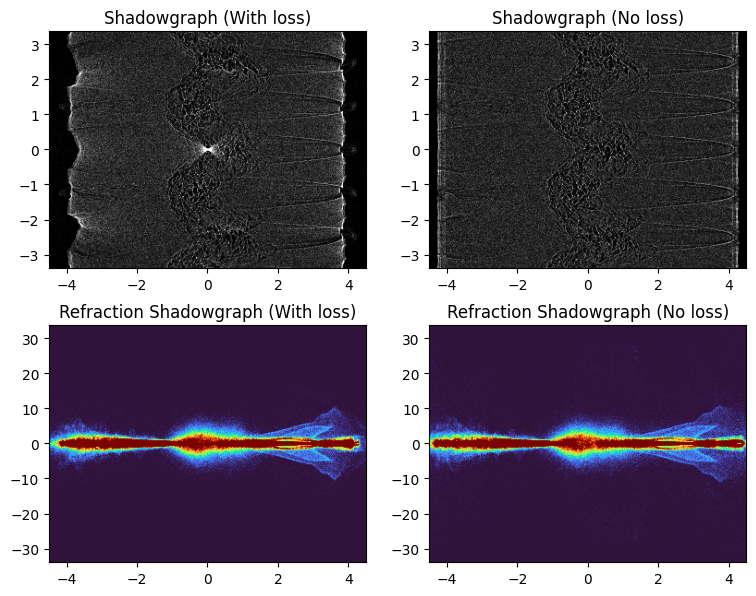

In [61]:
from utils.imaging import Image
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(9, 7))
outer_grid = fig.add_gridspec(
    2, 2,
    height_ratios=[0.5, 0.5],
    width_ratios=[0.5, 0.5],
    wspace=0.2,
    hspace=0.2
)

cases = [
    (shadowgrapher, refractometer, "With loss"),
    (shadowgrapher_noloss, refractometer_noloss, "No loss"),
]

for i, (sh, rh, label) in enumerate(cases):
    scale_sh_x = sh.H.shape[1] / 9
    scale_sh_y = sh.H.shape[0] / 6.75

    L = 400  # mm, distance from volume to lens

    shadow_sh = Image(sh.H, 0, scale_sh_x, scale_sh_y, fliplr=True)
    o_sh = (int(sh.H.shape[1] / 2), int(sh.H.shape[0] / 2))
    shadow_sh.set_origin(o_sh)

    pixel_size = 13.5 / rh.H.shape[0]  # mm/px
    scale_phi = 1 / (2 * pixel_size / L * 1000)  # mrad
    refrac_sh = Image(rh.H, 0, scale_sh_x, scale_phi, fliplr=False)
    o_rh = (int(rh.H.shape[1] / 2), int(rh.H.shape[0] / 2))
    refrac_sh.set_origin(o_rh)

    # axes
    ax1 = fig.add_subplot(outer_grid[0, i])
    ax2 = fig.add_subplot(outer_grid[1, i])

    # plots
    shadow_sh.plot_mm(ax1, cmap="Greys_r", aspect=scale_sh_y / scale_sh_x, clim=[0, 60])
    refrac_sh.plot_mm(ax2, cmap="turbo", aspect=scale_phi / scale_sh_x, clim=[refrac_sh.im.min(), 100])

    # titles
    ax1.set_title(f"Shadowgraph ({label})")
    ax2.set_title(f"Refraction Shadowgraph ({label})")


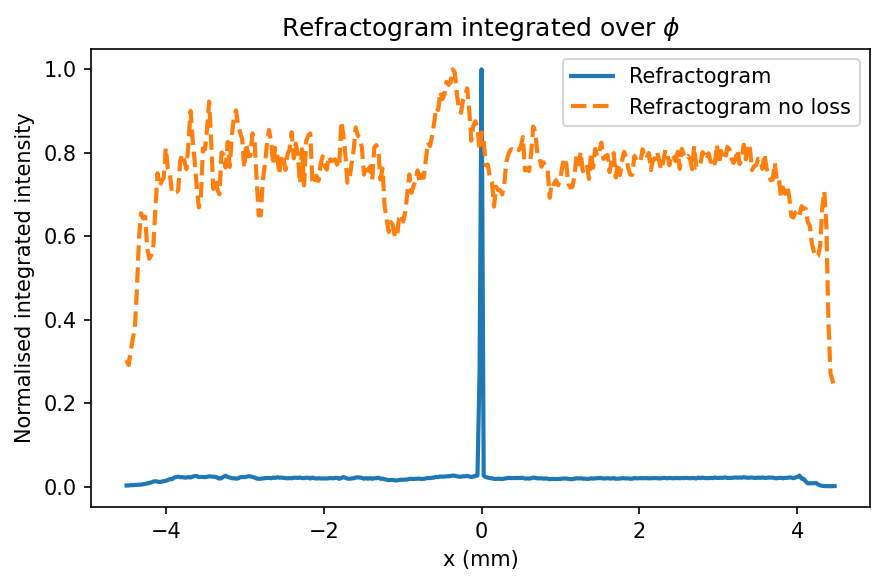

In [65]:
def integrate_along_phi(img):
    """
    Sum along phi (vertical axis), leaving profile vs x.
    """
    return np.sum(np.asarray(img, dtype=np.float64), axis=0)

def normalise_profile(p):
    p = np.asarray(p, dtype=float)
    m = np.nanmax(p)
    return p / m if m > 0 else p

# profiles
prof_loss   = integrate_along_phi(refractometer.H)
prof_noloss = integrate_along_phi(refractometer_noloss.H)

# x axis in mm
nx = refractometer.H.shape[1]
x_mm = (np.arange(nx) - nx/2) / scale_sh_x

# plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_mm, normalise_profile(prof_loss),   lw=2, label="Refractogram")
ax.plot(x_mm, normalise_profile(prof_noloss), lw=2, ls="--", label="Refractogram no loss")

ax.set_xlabel("x (mm)")
ax.set_ylabel("Normalised integrated intensity")
ax.set_title(r"Refractogram integrated over $\phi$")
ax.legend()
plt.tight_layout()
plt.show()